# Exploratory Data Analysis: Telecom Customer Churn

This notebook analyzes the `WA_Fn-UseC_-Telco-Customer-Churn.csv` dataset, forming our baseline 'Hard Signals' before we use an Agentic AI to generate 'Soft Signals' (synthetic ticket notes).

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configure visual settings
sns.set_theme(style='whitegrid')

# Data loading
data_path = r'../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(data_path)
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Cleaning
We have a quantitative column (`TotalCharges`) that is parsed as an `object` due to empty spaces. We need to coerce this into `numeric`.

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Missing values before drop: {df["TotalCharges"].isnull().sum()}')
df.dropna(inplace=True)
print(f'Shape after cleaning: {df.shape}')

Missing values before drop: 11
Shape after cleaning: (7032, 21)


## 2. Target Variable Analysis: Churn
Let's evaluate the class imbalance. This will inform whether we need to use scale_pos_weight in XGBoost or oversampling techniques like SMOTE.

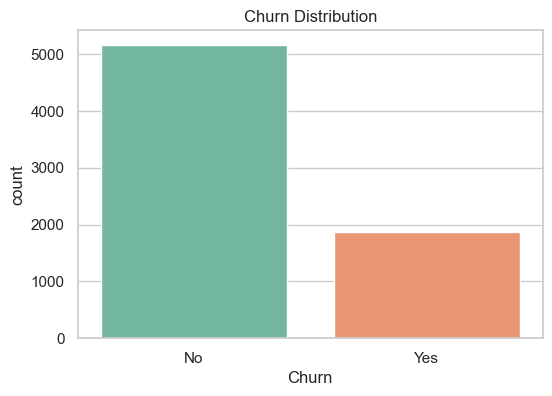

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.show()

## 3. Quantitative Variables vs Churn
The core 'Hard Signals' include billing logic (`MonthlyCharges`, `TotalCharges`) and customer loyalty (`tenure`).

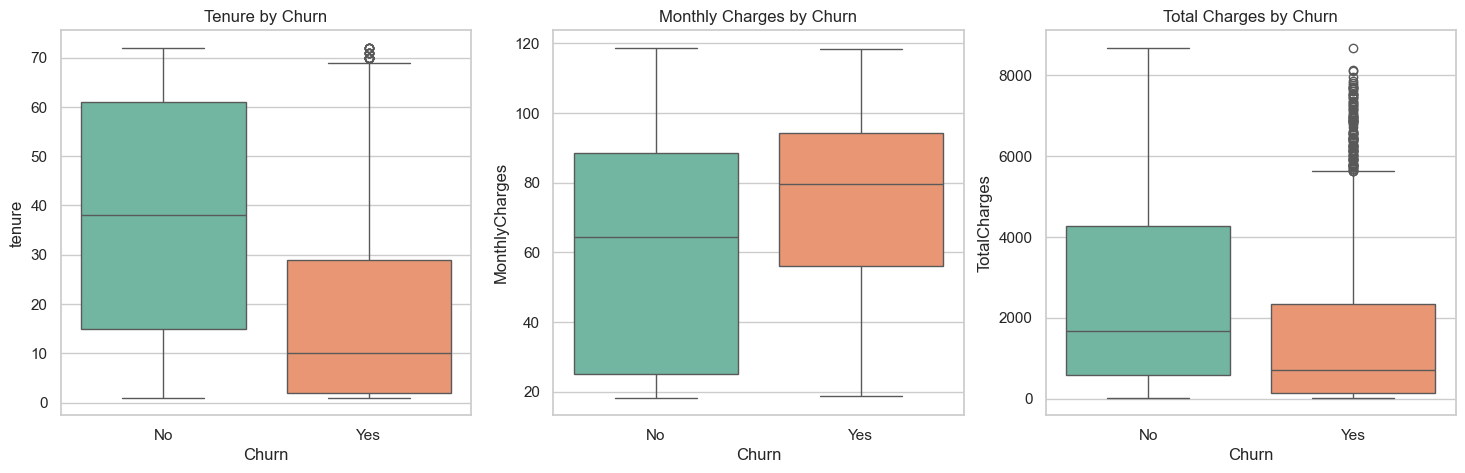

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], hue='Churn', palette='Set2')
axes[0].set_title('Tenure by Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], hue='Churn', palette='Set2')
axes[1].set_title('Monthly Charges by Churn')

sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[2], hue='Churn', palette='Set2')
axes[2].set_title('Total Charges by Churn')
plt.show()

## 4. Categorical Variables vs Churn
We investigate features that represent the quality of service (e.g., `InternetService`, `TechSupport`) and customer commitments (`Contract`). These will be highly important for generating Synthetic Ticket Notes.

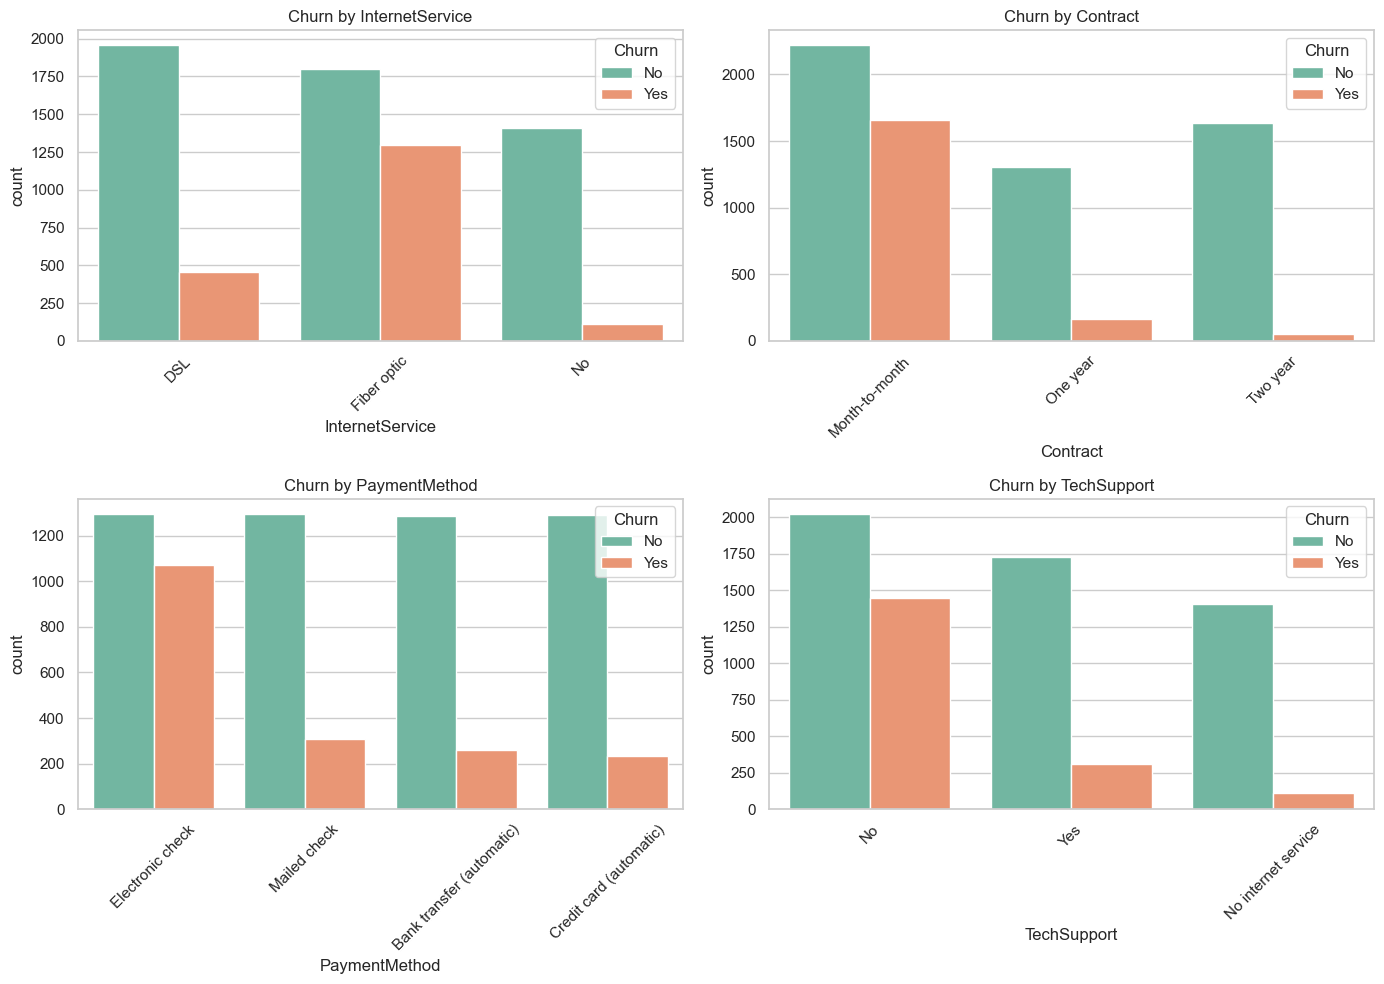

In [15]:
features = ['InternetService', 'Contract', 'PaymentMethod', 'TechSupport']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, feature in enumerate(features):
    ax = axes[i//2, i%2]
    sns.countplot(data=df, x=feature, hue='Churn', ax=ax, palette='Set2')
    ax.set_title(f'Churn by {feature}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Correlation & VIF Analysis
We drop redundant columns and encode categorical variables to check for multicollinearity.

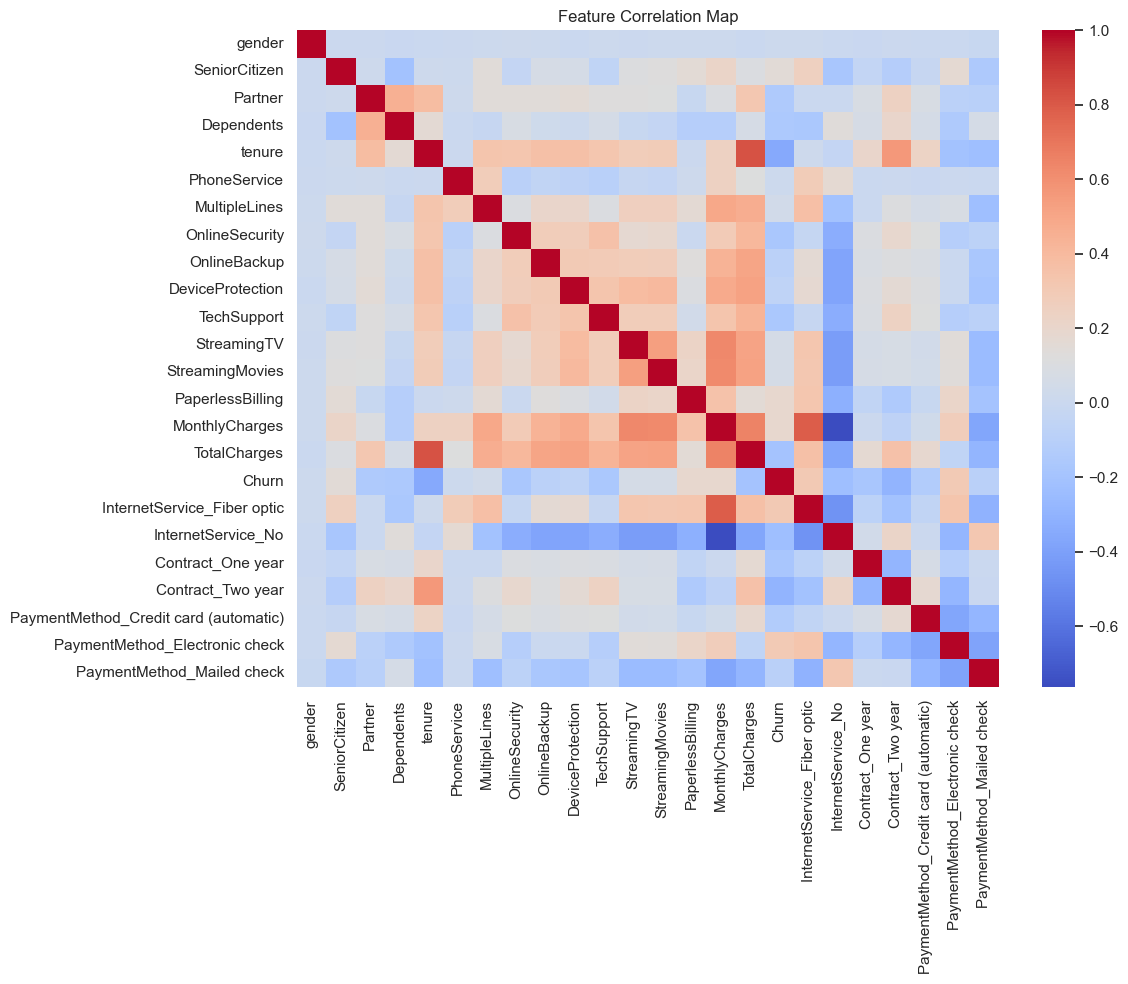

,Feature,VIF
14,MonthlyCharges,210.732469
5,PhoneService,47.068991
15,TotalCharges,21.381128
4,tenure,20.481420
16,InternetService_Fiber optic,17.539614
17,InternetService_No,8.235735
12,StreamingMovies,5.062488
11,StreamingTV,4.908939
19,Contract_Two year,3.487461
9,DeviceProtection,2.990143


In [16]:
# Collapse Redundant Columns
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})
replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in replace_cols:
    df[col] = df[col].replace({'No internet service': 'No'})

# Map Binary
bin_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']
for col in bin_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# Get Dummies
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), drop_first=True).astype(float)

# Correlation Map
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Map')
plt.tight_layout()
plt.show()

# VIF Calculation
X = df_encoded.drop('Churn', axis=1)
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
display(vif_data.sort_values(by='VIF', ascending=False))